<a href="https://colab.research.google.com/github/TeryYaki/UTS-BIG_DATA/blob/main/UTS_BIG_DATA_TERRY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
pip install google-play-scraper

In [11]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.canva.editor',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


📊 Total ulasan : 100
📅 Rentang data : 2026-05-01 s/d 2026-05-05
⏳ Memuat model RoBERTa... (tunggu 2-3 menit pertama kali)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model berhasil dimuat!
🧪 Tes: [{'label': 'positive', 'score': 0.9935092329978943}]
🔍 Menganalisis 100 ulasan...


  0%|          | 0/7 [00:00<?, ?it/s]

✅ Selesai!


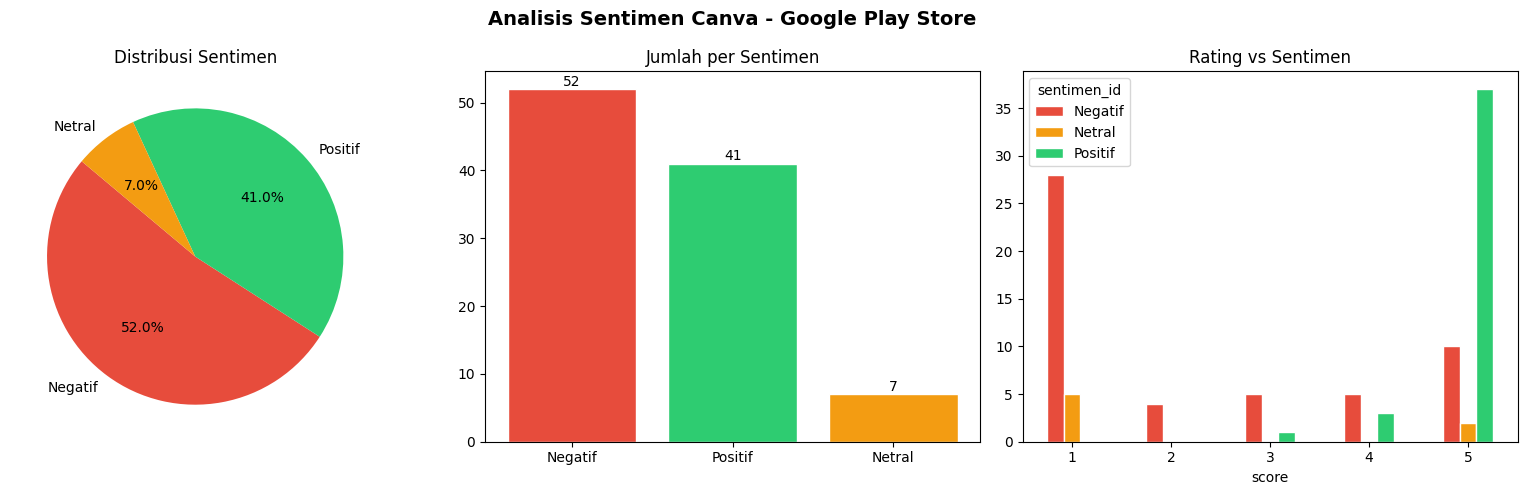

✅ Grafik disimpan!


In [12]:
import pandas as pd
from transformers import pipeline
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

df = pd.read_csv('ulasan_google_play.csv')
df['content'] = df['content'].fillna('').astype(str)
df['at'] = pd.to_datetime(df['at'])
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f'📊 Total ulasan : {len(df)}')
print(f'📅 Rentang data : {df["at"].min().date()} s/d {df["at"].max().date()}')
df.head()

MODEL_NAME = 'w11wo/indonesian-roberta-base-sentiment-classifier'
print(f'⏳ Memuat model RoBERTa... (tunggu 2-3 menit pertama kali)')

sentiment_pipeline = pipeline(
    task='text-classification',
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    truncation=True,
    max_length=512
)

print('✅ Model berhasil dimuat!')
test = sentiment_pipeline('Aplikasi ini sangat membantu!')
print(f'🧪 Tes: {test}')

texts = df['content'].tolist()
print(f'🔍 Menganalisis {len(texts)} ulasan...')

hasil_sentimen = []
BATCH_SIZE = 16

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    results = sentiment_pipeline(batch)
    hasil_sentimen.extend(results)

df['sentimen']   = [r['label'] for r in hasil_sentimen]
df['confidence'] = [round(r['score'], 4) for r in hasil_sentimen]

label_map = {
    'positive': 'Positif',
    'negative': 'Negatif',
    'neutral' : 'Netral',
}
df['sentimen_id'] = df['sentimen'].map(label_map).fillna(df['sentimen'])

print('✅ Selesai!')
df[['userName','score','sentimen_id','confidence','content']].head(10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Judul grafik telah diubah ke Canva
fig.suptitle('Analisis Sentimen Canva - Google Play Store', fontsize=14, fontweight='bold')

COLORS = {'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}
counts = df['sentimen_id'].value_counts()
colors_list = [COLORS.get(l, '#999') for l in counts.index]

axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_list, startangle=140)
axes[0].set_title('Distribusi Sentimen')

bars = axes[1].bar(counts.index, counts.values, color=colors_list, edgecolor='white')
axes[1].set_title('Jumlah per Sentimen')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(val), ha='center')

sentiment_rating = df.groupby(['score','sentimen_id']).size().unstack(fill_value=0)
sentiment_rating.plot(kind='bar', ax=axes[2],
                      color=[COLORS.get(c,'#999') for c in sentiment_rating.columns],
                      edgecolor='white')
axes[2].set_title('Rating vs Sentimen')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('hasil_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan!')